# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown blocks to this notebook and hand it in. Please use 42 as your random seed.


## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_train`, `X_test`, `y_train`, `y_test`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
car_prices = pd.read_excel("car_prices.xlsx")
labels = car_prices["Price (DKK)"]
#drop the label colum and coluElectric Range (km)ms that have correlation over 55%
data = car_prices.drop(columns=["Price (DKK)","Original Price (DKK)", "Top Speed (km/h)", "Horsepower (bhp)", "Battery Capacity (kWh)", "Electric Range (km)","Energy Consumption (Wh/km)"])
X = data
y = labels
#split the data, 80% training 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X

,Model Year,Mileage (km),Annual Road Tax (DKK),0-100 km/h (s),Towing Capacity (kg),Number of Doors,Rear-Wheel Drive,All-Wheel Drive (AWD),Front-Wheel Drive
0,2024,3000,780,7.9,1000,5,0,0,1
1,2024,1001,780,4.9,1800,5,0,1,0
2,2024,4000,780,7.8,750,5,0,0,1
3,2024,10,780,6.7,1000,5,1,0,0
4,2024,0,780,5.3,2500,5,0,1,0
...,...,...,...,...,...,...,...,...,...
6221,2023,12000,780,3.7,1600,5,0,1,0
6222,2021,90000,780,4.7,1500,5,0,1,0
6223,2023,11000,780,6.0,1600,5,1,0,0
6224,2017,90000,780,9.9,1000,5,0,0,1


## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.

Implement all the steps from the note "Linear_regression.pdf", i.e.

- Setup the normal equation and find the coefficient vector
- Find the predicted values and use these to determine the MSE and $R^2$
- Interpret the results





In [2]:
import numpy as np
from sklearn.preprocessing import add_dummy_feature
X_train_b = add_dummy_feature(X_train)
# Calculate the normal equation for training data
theta_best_train = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
theta_best_train

array([-1.79774883e+09,  8.58951452e+05,  2.88136865e+01,  4.25840002e+03,
        1.98569615e+05, -3.45071140e+02, -2.01337401e+05,  5.62251908e+07,
        5.67467862e+07,  5.63628389e+07])

### Predict on the test data

In [3]:
X_test_b = add_dummy_feature(X_test) #add bias collum
X_train_b = add_dummy_feature(X_train) #add bias collum
y_predict = X_test_b @ theta_best_train
y_predict_train = X_train_b @ theta_best_train
y_predict

array([ -390861.32139817,   -80118.09110861,  -172692.46766558, ...,
         725276.48479901,    67837.36429149, -3362467.78193913],
      shape=(1246,))

### Calculating MSE using the formula

In [4]:
# len is the number of values.
mse_test = np.sum((y_test  - y_predict)**2) / len(y_test)
mse_train = np.sum((y_train - y_predict_train)**2) / len(y_train)
print("Mse for training is: ",mse_train)
print("Mse for test is: ",mse_test)

Mse for training is:  1071150892057.0321
Mse for test is:  1241129719726.1304


### Calculating R^2

In [5]:
R2_test = 1 - np.sum((y_test - y_predict)**2)/np.sum((y_test - np.mean(y_test))**2)
R2_train = 1 - np.sum((y_train - y_predict_train)**2)/np.sum((y_train - np.mean(y_train))**2)
print("R2 for training is: ",R2_train)
print("R2 for test is: ",R2_test)

R2 for training is:  -47.33137933663995
R2 for test is:  -59.647026582533556


### Interpreting values
#### R2 = -3712.734787114262 < 0
Model performs worse than a baseline model
#### MSE =76000867234532.64
High MSE, lots of errors, inaccurate model

# Part 2: Using Library Functions

### Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


In [6]:
# Use this for Correlation and OLS. Add more code blocks if needed.
corr_matrix = X_train.corrwith(y_train) #idk if it is fully correct yet. this one doesn't work with heatmap
print("Correlation with Price:")
print(corr_matrix)

Correlation with Price:
Model Year               0.410882
Mileage (km)            -0.205943
Annual Road Tax (DKK)    0.073145
0-100 km/h (s)          -0.538535
Towing Capacity (kg)     0.356561
Number of Doors          0.144636
Rear-Wheel Drive         0.044100
All-Wheel Drive (AWD)    0.491236
Front-Wheel Drive       -0.475733
dtype: float64


### Visualisation of correlation_matrix with heatmap

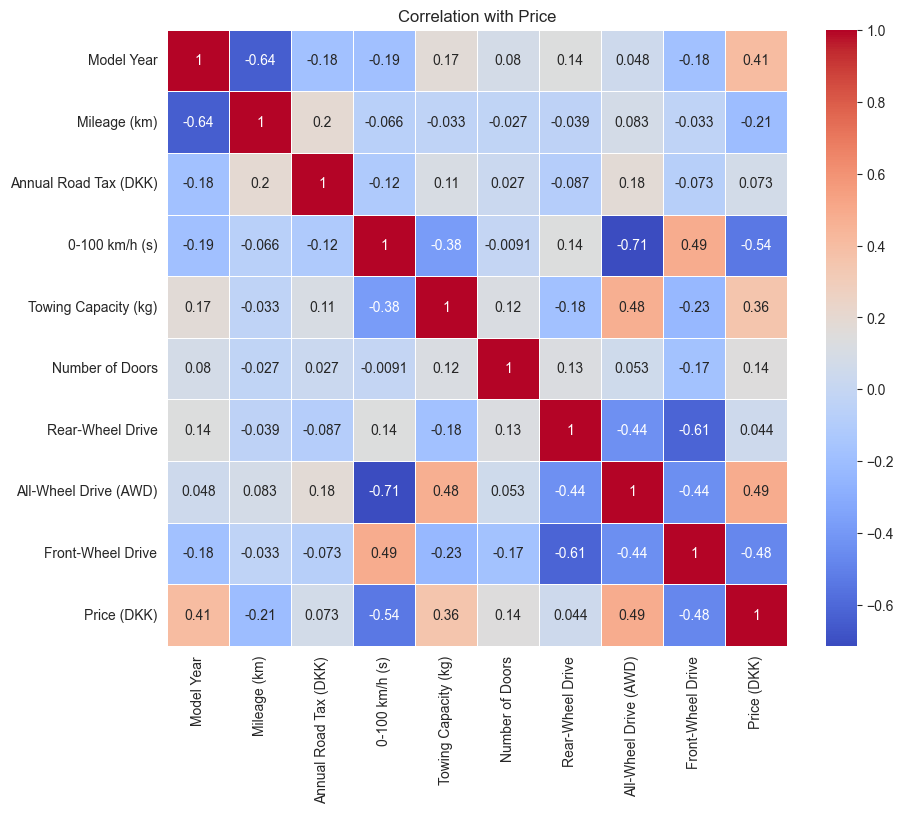

In [7]:
import seaborn as sns
data_with_target = X_train.copy()
data_with_target["Price (DKK)"] = y_train
# Calculate the correlation matrix including the target variable
correlation_matrix = data_with_target.corr()
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation with Price")
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
ols = LinearRegression()
ols.fit(X_train, y_train)
print("OLS =",ols.coef_)
RMSE_train = np.sqrt(mse_train)
RMSE_test = np.sqrt(mse_test)
print ("RMSE train =", RMSE_train)
print ("RMSE test =", RMSE_test)

OLS = [ 2.82542129e+04 -4.84734851e-01  2.89384499e+02 -1.90989642e+04
  3.04217798e+01  1.64182823e+04 -4.59179916e+02  6.41655603e+04
 -6.37063804e+04]
RMSE train = 1034964.1984421646
RMSE test = 1114060.0162137274


RMSE in the real world in this case would tell how much the model has an error in predicting the price for a given car
R2 represents how much the model explains variation in the car price based on the features used

### Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For this task you must do the following:
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [9]:
from sklearn.preprocessing import StandardScaler
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
# values to convert the pandas.Series into a numpy array to use reshape
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

### Ridge regression
#### impact of alpha hyperparameter on Ridge regression

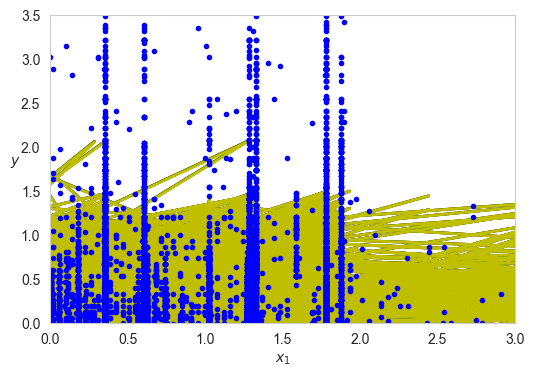

In [10]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
#calculate the sum at the bottom for R2 once since it does not change
bottom_sum_scaled = np.sum((y_test_scaled - np.mean(y_test_scaled))**2)
min_mse_ridge = 999999
for_min_mse_R2_ridge = 2
plt.figure(figsize=(6, 4))
for alpha, style in ((0.1, "r-"), (1, "g-"), (10, "y-")):
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X_train_scaled, y_train_scaled)
    y_ridge = ridge_reg.predict(X_test_scaled)
    mse_ridge = np.mean((y_test_scaled - y_ridge)**2)
    if (min_mse_ridge > mse_ridge):
        best_ridge_coef = ridge_reg.coef_
        best_alpha_ridge = alpha
        min_mse_ridge = mse_ridge
        for_min_mse_R2_ridge = (
                np.sum((y_test_scaled - y_ridge)**2)/
                bottom_sum_scaled)

    label_ridge = f"Ridge alpha={alpha}"
    plt.plot(X_test_scaled, y_ridge, style, label=label_ridge, linewidth=2)

plt.plot(X_train_scaled, y_train_scaled, "b.", linewidth=3)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [11]:
print("With best alpha", best_alpha_ridge)
print("MSE" , mse_ridge)
print("R2" , for_min_mse_R2_ridge)

With best alpha 10
MSE 0.4897920067831025
R2 0.53042684445131


### Lasso regression
#### impact of alpha hyperparameter on Lasso regression

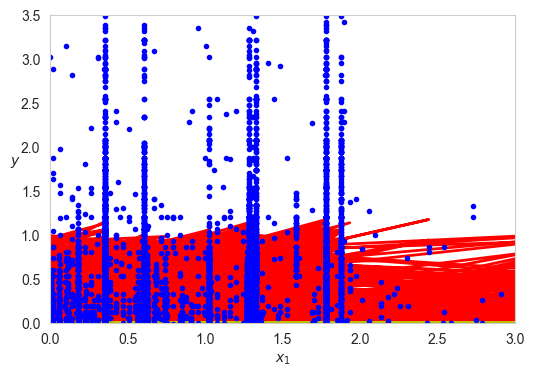

In [12]:
min_mse_lasso = 999999
for_min_mse_R2_lasso = 2
plt.figure(figsize=(6, 4))
for alpha, style in ((0.1, "r-"), (1, "g-"), (10, "y-")):
    lasso_reg = Lasso(alpha=alpha)
    lasso_reg.fit(X_train_scaled, y_train_scaled)
    y_lasso = lasso_reg.predict(X_test_scaled)
    mse_lasso = np.mean((y_test_scaled - y_lasso)**2)
    if(min_mse_lasso > mse_lasso):
        best_lasso_coef = lasso_reg.coef_
        best_alpha_lasso = alpha
        min_mse_lasso = mse_lasso
        for_min_mse_R2_lasso = (
                np.sum((y_test_scaled - y_lasso)**2)/
                bottom_sum_scaled)
    label_lasso = f"Lasso alpha={alpha}"
    plt.plot(X_test_scaled, y_lasso, style, label=label_lasso, linewidth=2)

plt.plot(X_train_scaled, y_train_scaled, "b.", linewidth=3)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [13]:
print("With best alpha", best_alpha_lasso)
print ("MSE" , min_mse_lasso)
print("R2" , for_min_mse_R2_lasso)

With best alpha 0.1
MSE 0.5120853675551587
R2 0.5545697394817978


### Elastic Net regression
#### impact of alpha and l1_ratio hyperparameters on Elastic Net regression
#### l1=1 corresponds to Lasso regression, l1=0 corresponds to Ridge regression, and values in between correspond to a combination of both

Note error still happens even with 1 mil iterations, idk

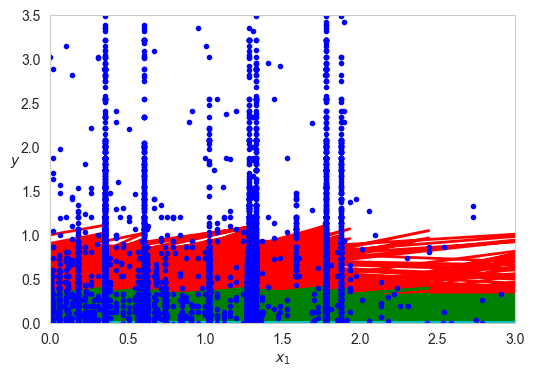

In [14]:
min_mse_net = 999999
for_min_mse_R2_net = 2
plt.figure(figsize=(6, 4))
for l1_ratio, style in ((0, "r-"), (0.3, "g-"), (1, "c-")):
    elastic_net_reg = ElasticNet(alpha=1, l1_ratio=l1_ratio, max_iter=100000)
    elastic_net_reg.fit(X_train_scaled, y_train_scaled)
    y_elastic_net = elastic_net_reg.predict(X_test_scaled)
    mse_elastic_net = np.mean((y_test_scaled - y_elastic_net)**2)
    # select the best case
    if(min_mse_net > mse_elastic_net):
        best_ratio_net = l1_ratio
        min_mse_net = mse_elastic_net
        for_min_mse_R2_net = (
                np.sum((y_test_scaled - y_elastic_net)**2)/
                bottom_sum_scaled)
    label_elastic_net = f"Elastic Net alpha={1} l1_ratio={l1_ratio}"
    plt.plot(X_test_scaled, y_elastic_net, style, label=label_elastic_net, linewidth=2)

plt.plot(X_train_scaled, y_train_scaled, "b.", linewidth=3)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [15]:
print ("With elastic net ratio" , best_ratio_net)
print ("MSE" , min_mse_net)
print("R2" , for_min_mse_R2_net)

With elastic net ratio 0
MSE 0.5167198438639647
R2 0.559588707962541


## Observation
After finding the most efficient alpha in the options given, it seems that even with a higher MSE the R2 of Elastic Net is the best at predicting, even with bigger errors it's strange that the accuracy is better.
Ols on scared data has much lower values than ols with unscaled data resulting in much higher accuracy seen in the MSE and R2 of the reggretion models

In [16]:
ols_scaled = LinearRegression()
ols_scaled.fit(X_train_scaled, y_train_scaled)
ridge_coefficients = best_ridge_coef
lasso_coefficients = best_lasso_coef
ols_coefficients = ols_scaled.coef_
# Get the name of each feature
feature_names = X.columns
# Get the absolute value of the coefficients and sort them to find the most important features

ridge_sorted_idx = np.argsort(np.abs(ridge_coefficients))[::-1]
lasso_sorted_idx = np.argsort(np.abs(lasso_coefficients))[::-1]
ols_sorted_idx = np.argsort(np.abs(ols_coefficients))[::-1]

# Get the top 5 most important features for each model

top_5_ridge_features = feature_names[ridge_sorted_idx][:5]
top_5_lasso_features = feature_names[lasso_sorted_idx][:5]
top_5_ols_features = feature_names[ols_sorted_idx][:5]

print("Top 5 Features from Ridge Model:")
for i, feature in enumerate(top_5_ridge_features, 1):
    print(f"{i}. {feature} (Coefficient: {ridge_coefficients[ridge_sorted_idx[i-1]]})")

print("\nTop 5 Features from Lasso Model:")
for i, feature in enumerate(top_5_lasso_features, 1):
    print(f"{i}. {feature} (Coefficient: {lasso_coefficients[lasso_sorted_idx[i-1]]})")

print("\nTop 5 Features from OLS Model:")
for i, feature in enumerate(top_5_ols_features, 1):
    print(f"{i}. {feature} (Coefficient: {ols_coefficients[ols_sorted_idx[i-1]]})")

Top 5 Features from Ridge Model:
1. Model Year (Coefficient: 0.2618892185956511)
2. 0-100 km/h (s) (Coefficient: -0.2267648317827281)
3. All-Wheel Drive (AWD) (Coefficient: 0.19891502642293768)
4. Front-Wheel Drive (Coefficient: -0.19052824998557805)
5. Mileage (km) (Coefficient: -0.08021301093759643)

Top 5 Features from Lasso Model:
1. Model Year (Coefficient: 0.23266854581516233)
2. 0-100 km/h (s) (Coefficient: -0.190481583235846)
3. Front-Wheel Drive (Coefficient: -0.16389150132463257)
4. All-Wheel Drive (AWD) (Coefficient: 0.15759787547136764)
5. Towing Capacity (kg) (Coefficient: 0.030344430660142453)

Top 5 Features from OLS Model:
1. Model Year (Coefficient: 0.2625301931913248)
2. 0-100 km/h (s) (Coefficient: -0.22689869601178866)
3. All-Wheel Drive (AWD) (Coefficient: 0.19914476842910955)
4. Front-Wheel Drive (Coefficient: -0.19067689098749743)
5. Mileage (km) (Coefficient: -0.08002564586674452)


We can see that all models consider
Model Year as the most important coefficient 0-100 km/h
being the second most important but afterwards the models disagree with the importance of some features

## Part 3: Classification

### kNN Classifier
In this final task, we go from a regression to a classification problem. Your goal is to classify cars as either **"Cheap"** or **"Expensive"** using the k-Nearest Neighbors (kNN) algorithm.

For this task you must do the following:
c   - Calculate the **median** of the original `Price (DKK)` column.
   - Create a new binary target variable, where:
     - `1` (Expensive) if the price is above the median.
     - `0` (Cheap) if the price is at or below the median.
- **Train-Test Split**
- **Feature Scaling**: Use the standardized (scaled) data from Task 5.
- **Model Implementation**:
   - Build a kNN classifier using `sklearn.neighbors.KNeighborsClassifier`.
   - Experiment with at least five different values for $k$ and at least 3 different distance metrics.
- **Evaluation**:
   - Find the best combination of $k$ and distance metric - the one that gives the highest accuracy score.
   - **Discussion**: Explain the trade-off of choosing a very small $k$ versus a very large $k$. Which value performed best for this dataset?

In [17]:
# Use this for Part 3. Add more code blocks if needed.
from sklearn.neighbors import KNeighborsClassifier
# original price median and binary set up
middle_price = y.median()
cheap_expensive = (y > middle_price).astype(int)
cheap_expensive.name = "Cheap/Expensive"
cheap_expensive_train, cheap_expensive_test = train_test_split(cheap_expensive, test_size=0.2, random_state=42)
cheap_expensive_test

239     1
1119    1
2215    1
2500    1
5783    1
       ..
3002    0
1025    0
1614    0
5153    1
3819    0
Name: Cheap/Expensive, Length: 1246, dtype: int64

In [18]:
model = KNeighborsClassifier()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)
# Make the prediction
model.fit(X_train_scaled_df, cheap_expensive_train) #if I use the data without labels, I would get a warning
y_predict_knn = model.predict(X_test_scaled_df)
print("Prediction: {}".format(y_predict_knn))
print("Accuracy score test: {}".format(model.score(X_test_scaled_df, cheap_expensive_test)))
print("Accuracy score train: {}".format(model.score(X_train_scaled_df, cheap_expensive_train)))

Prediction: [1 1 1 ... 0 1 0]
Accuracy score test: 0.8956661316211878
Accuracy score train: 0.9375502008032128


In [19]:
from sklearn.metrics import accuracy_score
neighbors_range = range(3, 20)  # Number of neighbors from 3 to 19
distance_metrics = ['euclidean', 'manhattan', 'minkowski']  # Common distance metrics, only illustration

# Variables to store the best parameters and highest accuracy
best_accuracy = 0
best_params = {'n_neighbors': None, 'metric': None}

# Nested loop to iterate over the hyperparameters
for n_neighbors in neighbors_range:
    for metric in distance_metrics:
        # Initialize the KNN model with current hyperparameters
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)

        # Train the model
        knn.fit(X_train_scaled_df, cheap_expensive_train)

        # Make predictions on the test set
        predictions = knn.predict(X_test_scaled_df)

        # Calculate the accuracy
        accuracy = accuracy_score(cheap_expensive_test, predictions)
        # To better look at the difference depending on each hyperparameter
        print(f"Current n_neighbors - {n_neighbors}, Metric - {metric}")
        print(f"Accuracy: {accuracy*100:.2f}%")
        # Update the best parameters if current accuracy is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params['n_neighbors'] = n_neighbors
            best_params['metric'] = metric

Current n_neighbors - 3, Metric - euclidean
Accuracy: 90.53%
Current n_neighbors - 3, Metric - manhattan
Accuracy: 90.69%
Current n_neighbors - 3, Metric - minkowski
Accuracy: 90.53%
Current n_neighbors - 4, Metric - euclidean
Accuracy: 89.89%
Current n_neighbors - 4, Metric - manhattan
Accuracy: 90.69%
Current n_neighbors - 4, Metric - minkowski
Accuracy: 89.89%
Current n_neighbors - 5, Metric - euclidean
Accuracy: 89.57%
Current n_neighbors - 5, Metric - manhattan
Accuracy: 90.29%
Current n_neighbors - 5, Metric - minkowski
Accuracy: 89.57%
Current n_neighbors - 6, Metric - euclidean
Accuracy: 89.73%
Current n_neighbors - 6, Metric - manhattan
Accuracy: 90.21%
Current n_neighbors - 6, Metric - minkowski
Accuracy: 89.73%
Current n_neighbors - 7, Metric - euclidean
Accuracy: 90.53%
Current n_neighbors - 7, Metric - manhattan
Accuracy: 90.93%
Current n_neighbors - 7, Metric - minkowski
Accuracy: 90.53%
Current n_neighbors - 8, Metric - euclidean
Accuracy: 90.53%
Current n_neighbors - 8,

In [20]:
# Print the best set of parameters and the highest accuracy achieved
print(f"Best parameters: Number of Neighbors - {best_params['n_neighbors']}, Distance Metric - {best_params['metric']}")
print(f"Highest Accuracy: {best_accuracy*100:.2f}%")

Best parameters: Number of Neighbors - 10, Distance Metric - manhattan
Highest Accuracy: 91.01%


# Observation
Depending on the K in KNN 2 things happen, if the K is too little our model ends up overfitting, while a too large K ends up underfitting.
Depending on the data, experiment until K has best accuracy with least bias.